## 1. Setup and Imports

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')
CUSTOM_DATA_PATH = "datasets"
os.makedirs(CUSTOM_DATA_PATH, exist_ok=True)
os.environ['KAGGLEHUB_CACHE'] = CUSTOM_DATA_PATH  # older versions
os.environ['KAGGLE_CACHE_DIR'] = CUSTOM_DATA_PATH  # some versions
os.environ['KAGGLEHUB_HOME'] = CUSTOM_DATA_PATH    # newer versions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import kagglehub

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Enable optimizations if available
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    if hasattr(torch.backends.cudnn, 'allow_tf32'):
        torch.backends.cudnn.allow_tf32 = True
    if hasattr(torch.cuda, 'matmul'):
        torch.backends.cuda.matmul.allow_tf32 = True

print("✅ Setup complete")

# ImageNet normalization for pretrained backbone
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


Using device: cuda
✅ Setup complete


## 2. Configuration

In [2]:
OPTION_NAME = "option9"

CHECKPOINT_DATASET_NAME = f"{OPTION_NAME}-ssl-checkpoints"
RESUME_SSL_PRETRAINING = True
RESUME_FINETUNING = False
SSL_CHECKPOINT_FILE = "latest"
FINETUNE_CHECKPOINT_FILE = "latest"

class CFG:
    # Data
    img_size = 224
    in_channels = 2  # grayscale image + segmentation mask
    
    # Training
    batch_size = 64
    pretrain_epochs = 50       
    finetune_epochs = 100
    
    # ============================================
    # 🎛️ FINE-TUNING HYPERPARAMETERS (TUNE THESE)
    # ============================================
    
    # Learning rates
    finetune_lr = 5e-4              # Classifier head LR — try: [1e-4, 3e-4, 5e-4, 1e-3]
    backbone_lr_multiplier = 0.1    # Backbone LR = finetune_lr * this — try: [0.01, 0.05, 0.1, 0.2]
    
    # Regularization
    weight_decay = 1e-4             # AdamW weight decay — try: [1e-5, 1e-4, 1e-3]
    dropout_rate = 0.3              # Classifier head dropout — try: [0.2, 0.3, 0.4, 0.5]
    label_smoothing = 0.05          # Label smoothing — try: [0.0, 0.05, 0.1]
    gradient_clip_val = 1.0         # Max gradient norm (0 = no clipping) — try: [0, 1.0, 5.0]
    
    # LR Schedule
    scheduler_type = "cosine"       # LR scheduler — try: ["plateau", "cosine"]
    warmup_epochs = 3               # Linear warmup epochs — try: [0, 3, 5]
    patience = 5                    # ReduceLROnPlateau patience (only if scheduler_type="plateau")
    
    # Backbone freeze strategy
    freeze_backbone_epochs = 3      # Freeze backbone for first N epochs — try: [0, 3, 5]
    
    # Loss function
    focal_gamma = 2.0               # Focal loss gamma — try: [1.0, 2.0, 3.0]
    focal_alpha = 1.0               # Focal loss alpha — try: [0.5, 0.75, 1.0]
    
    # Early stopping
    early_stopping_patience = 15    # Stop if no improvement for N epochs — try: [10, 15, 20]
    
    # SSL
    pretrain_lr = 1e-3
    temperature = 0.5
    projection_dim = 128
    
    # Device
    device = device
    
    # Subset for testing (set to None for full dataset)
    subset_size = None
    
    # Fine-tuning data fraction (1.0 = use all training data)
    finetune_fraction = 1

cfg = CFG()
print(f"Configuration: img_size={cfg.img_size}, in_channels={cfg.in_channels}")
print(f"Pretrain: {cfg.pretrain_epochs} epochs, Finetune: {cfg.finetune_epochs} epochs")
print(f"Batch size: {cfg.batch_size}, AdamW weight_decay: {cfg.weight_decay}")
print(f"Fine-tune fraction: {cfg.finetune_fraction} of training data")
print(f"\n🎛️ Fine-tuning hyperparameters:")
print(f"   Classifier LR: {cfg.finetune_lr}, Backbone LR mult: {cfg.backbone_lr_multiplier}")
print(f"   Dropout: {cfg.dropout_rate}, Label smoothing: {cfg.label_smoothing}")
print(f"   Warmup: {cfg.warmup_epochs} epochs, Freeze backbone: {cfg.freeze_backbone_epochs} epochs")
print(f"   Scheduler: {cfg.scheduler_type}, Gradient clip: {cfg.gradient_clip_val}")
print(f"   Focal loss: gamma={cfg.focal_gamma}, alpha={cfg.focal_alpha}")
print(f"   Early stopping patience: {cfg.early_stopping_patience}")


Configuration: img_size=224, in_channels=2
Pretrain: 50 epochs, Finetune: 100 epochs
Batch size: 64, AdamW weight_decay: 0.0001
Fine-tune fraction: 1 of training data

🎛️ Fine-tuning hyperparameters:
   Classifier LR: 0.0005, Backbone LR mult: 0.1
   Dropout: 0.3, Label smoothing: 0.05
   Warmup: 3 epochs, Freeze backbone: 3 epochs
   Scheduler: cosine, Gradient clip: 1.0
   Focal loss: gamma=2.0, alpha=1.0
   Early stopping patience: 15


## 3. Data Loading

In [3]:
# Check environment and load data
IN_KAGGLE = os.path.exists('/kaggle/input')

if IN_KAGGLE:
    data_dir = Path('/kaggle/input/nih-chest-xrays')
    checkpoint_dir = Path('/kaggle/working/checkpoints')
    CHEXPERT_PATH = Path('/kaggle/input/chexpert/CheXpert-v1.0-small')
else:
    data_dir = Path(kagglehub.dataset_download('nih-chest-xrays/data'))
    checkpoint_dir = Path('./checkpoints')

    # Download CheXpert-Small for SSL Pretraining
    print("Downloading CheXpert-Small...")
    cx_path = kagglehub.dataset_download('ashery/chexpert')
    CHEXPERT_PATH = Path(cx_path)

checkpoint_dir.mkdir(parents=True, exist_ok=True)
print(f"Data directory: {data_dir}")
print(f"CheXpert directory: {CHEXPERT_PATH}")
print(f"Checkpoint directory: {checkpoint_dir}")


Data directory: datasets/datasets/nih-chest-xrays/data/versions/3
CheXpert directory: datasets/datasets/ashery/chexpert/versions/1
Checkpoint directory: checkpoints


In [4]:
# Load metadata
csv_path = data_dir / 'Data_Entry_2017.csv'
df = pd.read_csv(csv_path)

# Disease categories
disease_categories = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass',
    'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema',
    'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia'
]

# Create binary labels for each disease
for disease in disease_categories:
    df[disease] = df['Finding Labels'].apply(lambda x: 1 if disease in x else 0)

# Find image paths
image_dirs = list(data_dir.glob('images_*/images'))
if not image_dirs:
    image_dirs = [data_dir / 'images']

image_path_map = {}
for img_dir in image_dirs:
    for img_path in img_dir.glob('*.png'):
        image_path_map[img_path.name] = str(img_path)

df['Image Path'] = df['Image Index'].map(image_path_map)
df = df.dropna(subset=['Image Path'])

if cfg.subset_size:
    df = df.sample(n=min(cfg.subset_size, len(df)), random_state=42)

print(f"Total samples: {len(df)}")
print(f"Disease distribution:")
print(df[disease_categories].sum())

Total samples: 112120
Disease distribution:
Atelectasis           11559
Cardiomegaly           2776
Effusion              13317
Infiltration          19894
Mass                   5782
Nodule                 6331
Pneumonia              1431
Pneumothorax           5302
Consolidation          4667
Edema                  2303
Emphysema              2516
Fibrosis               1686
Pleural_Thickening     3385
Hernia                  227
dtype: int64


## 3.5. Checkpoint & Resume Configuration

In [5]:
# ============================================
# 💾 Checkpoint & Resume Configuration
# ============================================

import shutil
from datetime import datetime

if IN_KAGGLE:
    CHECKPOINT_DIR = '/kaggle/working/checkpoints'
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    
    # Load checkpoints from ALL versions of the dataset
    input_path = '/kaggle/input'
    if os.path.exists(input_path):
        found_any = False
        for dataset_folder in sorted(os.listdir(input_path)):
            if dataset_folder.startswith(CHECKPOINT_DATASET_NAME):
                dataset_path = os.path.join(input_path, dataset_folder)
                if os.path.isdir(dataset_path):
                    # Check for .pth files in multiple locations
                    search_paths = [dataset_path]
                    
                    checkpoints_subdir = os.path.join(dataset_path, 'checkpoints')
                    if os.path.isdir(checkpoints_subdir):
                        search_paths.append(checkpoints_subdir)
                    
                    for item in os.listdir(dataset_path):
                        item_path = os.path.join(dataset_path, item)
                        if os.path.isdir(item_path) and item != 'checkpoints':
                            search_paths.append(item_path)
                    
                    for search_path in search_paths:
                        pth_files = [f for f in os.listdir(search_path) if f.endswith('.pth')]
                        if pth_files:
                            found_any = True
                            rel_path = os.path.relpath(search_path, input_path)
                            print(f"📂 Found checkpoints in: {rel_path}")
                            for f in pth_files:
                                src = os.path.join(search_path, f)
                                dst = os.path.join(CHECKPOINT_DIR, f)
                                if not os.path.exists(dst):
                                    shutil.copy2(src, dst)
                                    print(f"   📦 Copied: {f}")
                                else:
                                    src_time = os.path.getmtime(src)
                                    dst_time = os.path.getmtime(dst)
                                    if src_time > dst_time:
                                        shutil.copy2(src, dst)
                                        print(f"   🔄 Updated: {f} (newer version)")
        
        if not found_any:
            print(f"ℹ️ No checkpoint datasets found matching: {CHECKPOINT_DATASET_NAME}*")
    
    existing = [f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.pth')]
    if existing:
        print(f"✅ Total checkpoints available: {len(existing)}")
    else:
        print(f"ℹ️ Starting fresh - no checkpoints loaded")
        
else:
    CHECKPOINT_DIR = str(checkpoint_dir)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def save_checkpoint(state, filename):
    filepath = os.path.join(CHECKPOINT_DIR, filename)
    state['saved_at'] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    torch.save(state, filepath)
    print(f"💾 Saved: {filename}")
    if IN_KAGGLE: torch.save(state, f'/kaggle/working/{filename}')

def load_checkpoint(filename):
    filepath = os.path.join(CHECKPOINT_DIR, filename)
    if os.path.exists(filepath):
        checkpoint = torch.load(filepath, map_location=cfg.device, weights_only=False)
        print(f"✅ Loaded: {filename}")
        return checkpoint
    return None

def find_latest_checkpoint(prefix):
    if not os.path.exists(CHECKPOINT_DIR): return None
    latest = f'{prefix}_latest.pth'
    if os.path.exists(os.path.join(CHECKPOINT_DIR, latest)): return latest
    import re
    pattern = re.compile(rf'{prefix}_epoch(\d+)\.pth')
    max_epoch, best = -1, None
    for f in os.listdir(CHECKPOINT_DIR):
        m = pattern.match(f)
        if m and int(m.group(1)) > max_epoch: max_epoch, best = int(m.group(1)), f
    return best

print(f"🔧 Environment: {'Kaggle' if IN_KAGGLE else 'Local'}")
print(f"📂 Checkpoint dir: {CHECKPOINT_DIR}")


🔧 Environment: Local
📂 Checkpoint dir: checkpoints


## 4. Rule-Based Lung Segmentation

In [6]:
# ============================================
# Load Pre-Computed Lung Masks (Lazy from Disk)
# ============================================
# Masks pre-computed by precompute_lung_masks.ipynb (NIH)
# and precompute_lung_masks_chexpert.ipynb (CheXpert)
# Loaded on-demand in __getitem__ to avoid massive memory usage.

if IN_KAGGLE:
    NIH_PIXEL_MASK_DIR = "/kaggle/working/lung_masks/pixel_masks"
    CHEXPERT_PIXEL_MASK_DIR = "/kaggle/working/lung_masks_chexpert/pixel_masks"
else:
    NIH_PIXEL_MASK_DIR = "./lung_masks/pixel_masks"
    CHEXPERT_PIXEL_MASK_DIR = "./lung_masks_chexpert/pixel_masks"

def load_pixel_mask(img_name, img_path, img_size=224):
    """Load a single pixel mask from disk on-demand.
    Routes to NIH or CheXpert mask directory based on image path.
    """
    is_chexpert = 'chexpert' in str(img_path).lower()
    mask_dir = CHEXPERT_PIXEL_MASK_DIR if is_chexpert else NIH_PIXEL_MASK_DIR
    mask_name = img_name.replace(".png", "").replace(".jpg", "").replace("/", "_")
    mask_path = os.path.join(mask_dir, f"{mask_name}.npy")

    if os.path.exists(mask_path):
        mask = np.load(mask_path)
        if mask.dtype == np.uint8:
            mask = mask.astype(np.float32) / 255.0
        if mask.shape[0] != img_size or mask.shape[1] != img_size:
            mask = cv2.resize(mask, (img_size, img_size))
        return mask
    else:
        return np.zeros((img_size, img_size), dtype=np.float32)

print(f"NIH pixel mask directory: {NIH_PIXEL_MASK_DIR}")
print(f"CheXpert pixel mask directory: {CHEXPERT_PIXEL_MASK_DIR}")
print("Masks will be loaded lazily from disk (no bulk preloading)")


NIH pixel mask directory: ./lung_masks/pixel_masks
CheXpert pixel mask directory: ./lung_masks_chexpert/pixel_masks
Masks will be loaded lazily from disk (no bulk preloading)


## 5. Dataset Classes

In [7]:
class SSLAugmentation:
    """Augmentations for SSL pretraining."""
    def __init__(self, img_size=224):
        self.img_size = img_size
    
    def __call__(self, image, mask):
        # Random horizontal flip (both image and mask)
        if np.random.random() > 0.5:
            image = np.fliplr(image).copy()
            mask = np.fliplr(mask).copy()
        
        # Random rotation
        if np.random.random() > 0.3:
            angle = np.random.uniform(-15, 15)
            h, w = image.shape[:2]
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            image = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
            mask = cv2.warpAffine(mask, M, (w, h), borderMode=cv2.BORDER_CONSTANT)
        
        # Random resized crop (0.8-1.0)
        if np.random.random() > 0.3:
            h, w = image.shape[:2]
            crop_scale = np.random.uniform(0.8, 1.0)
            ch, cw = int(h * crop_scale), int(w * crop_scale)
            top = np.random.randint(0, h - ch + 1)
            left = np.random.randint(0, w - cw + 1)
            image = cv2.resize(image[top:top+ch, left:left+cw], (self.img_size, self.img_size))
            mask = cv2.resize(mask[top:top+ch, left:left+cw], (self.img_size, self.img_size))
        
        # Brightness + contrast (image only)
        if np.random.random() > 0.3:
            alpha = np.random.uniform(0.8, 1.2)
            beta = np.random.uniform(-0.1, 0.1)
            image = np.clip(alpha * image + beta, 0, 1)
        
        # Gaussian noise (image only)
        if np.random.random() > 0.5:
            noise = np.random.normal(0, 0.02, image.shape).astype(np.float32)
            image = np.clip(image + noise, 0, 1)
        
        mask = (mask > 0.5).astype(np.float32)
        return image.astype(np.float32), mask.astype(np.float32)


def to_2ch_normalized(image, mask):
    """Stack image+mask as 2-channel tensor with ImageNet-inspired normalization."""
    gray_mean = 0.449
    gray_std = 0.226
    image_norm = (image - gray_mean) / gray_std
    stacked = np.stack([image_norm, mask], axis=0)  # (2, H, W)
    return torch.from_numpy(stacked).float()


class SSLPretrainDataset(Dataset):
    """SSL pretraining dataset — loads masks lazily from disk."""
    
    def __init__(self, df, img_size=224):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.augmentation = SSLAugmentation(img_size)
        self.paths = df['Image Path'].tolist()
        self.img_names = df['Image Index'].tolist()
        print(f"📦 SSLPretrainDataset: {len(self.df)} samples (masks loaded lazily from disk)")
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx], cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img.astype(np.float32) / 255.0
        
        # Load mask lazily from disk
        mask = load_pixel_mask(self.img_names[idx], self.paths[idx], self.img_size)
        
        # Two augmented views
        img1, mask1 = self.augmentation(img.copy(), mask.copy())
        img2, mask2 = self.augmentation(img.copy(), mask.copy())
        
        view1 = to_2ch_normalized(img1, mask1)
        view2 = to_2ch_normalized(img2, mask2)
        return view1, view2


class ClassificationDataset(Dataset):
    """Classification dataset — loads masks lazily from disk."""
    
    def __init__(self, df, disease_categories, img_size=224, augment=False):
        self.df = df.reset_index(drop=True)
        self.disease_categories = disease_categories
        self.img_size = img_size
        self.augment = augment
        self.labels = torch.tensor(df[disease_categories].values.astype(np.float32))
        self.paths = df['Image Path'].tolist()
        self.img_names = df['Image Index'].tolist()
        print(f"📦 ClassificationDataset: {len(self.df)} samples (augment={augment}, masks from disk)")
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx], cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img.astype(np.float32) / 255.0
        
        # Load mask lazily from disk
        mask = load_pixel_mask(self.img_names[idx], self.paths[idx], self.img_size)
        
        if self.augment:
            if np.random.random() > 0.5:
                img = np.fliplr(img).copy()
                mask = np.fliplr(mask).copy()
            alpha = np.random.uniform(0.9, 1.1)
            beta = np.random.uniform(-0.05, 0.05)
            img = np.clip(alpha * img + beta, 0, 1)
            if np.random.random() > 0.5:
                h, w = img.shape[:2]
                crop_scale = np.random.uniform(0.85, 1.0)
                ch, cw = int(h * crop_scale), int(w * crop_scale)
                top = np.random.randint(0, h - ch + 1)
                left = np.random.randint(0, w - cw + 1)
                img = cv2.resize(img[top:top+ch, left:left+cw], (self.img_size, self.img_size))
                mask = cv2.resize(mask[top:top+ch, left:left+cw], (self.img_size, self.img_size))
        
        mask = (mask > 0.5).astype(np.float32)
        tensor = to_2ch_normalized(img, mask)
        return tensor, self.labels[idx]


print("✅ Dataset classes defined (masks loaded lazily from disk)")


✅ Dataset classes defined (masks loaded lazily from disk)


## 6. Model Architecture

In [8]:
def get_resnet50_multichannel(in_channels=2, pretrained=True):
    """
    Create a ResNet50 backbone modified for 2-channel input.
    Adapts pretrained weights by averaging RGB channels.
    """
    model = models.resnet50(pretrained=pretrained)
    
    # Get original first conv layer
    original_conv = model.conv1
    
    # Create new conv layer with desired input channels
    new_conv = nn.Conv2d(
        in_channels=in_channels,
        out_channels=original_conv.out_channels,
        kernel_size=original_conv.kernel_size,
        stride=original_conv.stride,
        padding=original_conv.padding,
        bias=original_conv.bias is not None
    )
    
    # Initialize weights from pretrained model
    with torch.no_grad():
        if pretrained:
            # Average the RGB weights and replicate for each input channel
            original_weights = original_conv.weight.data
            avg_weight = original_weights.mean(dim=1, keepdim=True)
            new_conv.weight.data = torch.cat([avg_weight] * in_channels, dim=1)
            
            if original_conv.bias is not None:
                new_conv.bias.data = original_conv.bias.data.clone()
    
    model.conv1 = new_conv
    return model


class ProjectionHead(nn.Module):
    """Projection head for contrastive learning."""
    
    def __init__(self, in_dim, hidden_dim=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim)
        )
    
    def forward(self, x):
        return self.net(x)


class SSLModel(nn.Module):
    """SSL model with ResNet50 backbone and projection head."""
    
    def __init__(self, in_channels=2, projection_dim=128, pretrained=True):
        super().__init__()
        
        # Backbone
        self.backbone = get_resnet50_multichannel(in_channels, pretrained)
        self.feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        
        # Projection head for SSL
        self.projection = ProjectionHead(self.feature_dim, out_dim=projection_dim)
    
    def forward(self, x):
        features = self.backbone(x)
        projections = self.projection(features)
        return F.normalize(projections, dim=1)
    
    def get_features(self, x):
        return self.backbone(x)


class ClassificationModel(nn.Module):
    """Classification model using pretrained SSL backbone.
    
    Args:
        ssl_model: Pretrained SSL model to extract backbone from
        num_classes: Number of output classes
        dropout_rate: Dropout probability for classifier head
        freeze_backbone: Whether to freeze backbone parameters initially
    """
    
    def __init__(self, ssl_model, num_classes=14, dropout_rate=0.3, freeze_backbone=False):
        super().__init__()
        self.backbone = ssl_model.backbone
        self.feature_dim = ssl_model.feature_dim
        
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.feature_dim, num_classes)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)
    
    def freeze_backbone(self):
        """Freeze all backbone parameters."""
        for param in self.backbone.parameters():
            param.requires_grad = False
    
    def unfreeze_backbone(self):
        """Unfreeze all backbone parameters."""
        for param in self.backbone.parameters():
            param.requires_grad = True

print("✅ Model classes defined")


✅ Model classes defined


## 7. Contrastive Loss

In [9]:
class NTXentLoss(nn.Module):
    """NT-Xent loss for contrastive learning (SimCLR)."""
    
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
    
    def forward(self, z1, z2):
        batch_size = z1.shape[0]
        
        # Concatenate representations
        z = torch.cat([z1, z2], dim=0)
        
        # Compute similarity matrix
        sim = torch.mm(z, z.t()) / self.temperature
        
        # Create mask for positive pairs
        mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
        
        # Mask out self-similarities
        sim.masked_fill_(mask, float('-inf'))
        
        # Labels: positive pairs are at positions batch_size apart
        labels = torch.cat([
            torch.arange(batch_size, 2 * batch_size),
            torch.arange(batch_size)
        ]).to(z.device)
        
        loss = F.cross_entropy(sim, labels)
        return loss

print("✅ Contrastive loss defined")


class FocalLoss(nn.Module):
    """Focal Loss for class-imbalanced multi-label classification.
    
    Args:
        alpha: Weighting factor for focal loss
        gamma: Focusing parameter — higher gamma focuses more on hard examples
        label_smoothing: Smoothing factor (0 = no smoothing, 0.1 = moderate smoothing)
    """
    def __init__(self, alpha=1, gamma=2, label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing
    
    def forward(self, logits, targets):
        # Apply label smoothing
        if self.label_smoothing > 0:
            targets = targets * (1 - self.label_smoothing) + 0.5 * self.label_smoothing
        
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()

print("✅ Loss functions: NTXentLoss, FocalLoss (with label smoothing support)")


✅ Contrastive loss defined
✅ Loss functions: NTXentLoss, FocalLoss (with label smoothing support)


## 8. Training Functions

In [10]:
def pretrain_epoch(model, dataloader, optimizer, criterion, device):
    """Run one pretraining epoch."""
    model.train()
    total_loss = 0
    
    pbar = tqdm(dataloader, desc="Pretraining")
    for view1, view2 in pbar:
        view1, view2 = view1.to(device), view2.to(device)
        
        optimizer.zero_grad()
        
        z1 = model(view1)
        z2 = model(view2)
        
        loss = criterion(z1, z2)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})
    
    return total_loss / len(dataloader)


def finetune_epoch(model, dataloader, optimizer, criterion, device, gradient_clip_val=0):
    """Run one fine-tuning epoch with optional gradient clipping.
    
    Args:
        gradient_clip_val: Max gradient norm. 0 means no clipping.
    """
    model.train()
    total_loss = 0
    
    pbar = tqdm(dataloader, desc="Fine-tuning")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Optional gradient clipping
        if gradient_clip_val > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip_val)
        
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})
    
    return total_loss / len(dataloader)


@torch.no_grad()
def evaluate(model, dataloader, device):
    """Evaluate model and return AUC scores."""
    model.eval()
    all_preds = []
    all_labels = []
    
    for images, labels in tqdm(dataloader, desc="Evaluating"):
        images = images.to(device)
        outputs = torch.sigmoid(model(images))
        all_preds.append(outputs.cpu().numpy())
        all_labels.append(labels.numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    # Calculate AUC for each disease
    aucs = []
    for i in range(all_labels.shape[1]):
        if all_labels[:, i].sum() > 0:  # Only if there are positive samples
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
            aucs.append(auc)
        else:
            aucs.append(0.5)
    
    return np.mean(aucs), aucs


class LinearWarmupScheduler:
    """Linear warmup scheduler that wraps another scheduler.
    
    During warmup_epochs, linearly ramps LR from a small value to the target.
    After warmup, delegates to the wrapped scheduler.
    """
    def __init__(self, optimizer, warmup_epochs, after_scheduler=None):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.after_scheduler = after_scheduler
        self.current_epoch = 0
        # Store base LRs
        self.base_lrs = [pg["lr"] for pg in optimizer.param_groups]
        # Start from 1/10 of the target LR
        if warmup_epochs > 0:
            for pg in optimizer.param_groups:
                pg["lr"] = pg["lr"] * 0.1
    
    def step(self, metrics=None):
        self.current_epoch += 1
        if self.current_epoch <= self.warmup_epochs:
            # Linear warmup: ramp from 10% to 100% of target LR
            warmup_factor = 0.1 + 0.9 * (self.current_epoch / self.warmup_epochs)
            for pg, base_lr in zip(self.optimizer.param_groups, self.base_lrs):
                pg["lr"] = base_lr * warmup_factor
        elif self.after_scheduler is not None:
            if metrics is not None:
                self.after_scheduler.step(metrics)
            else:
                self.after_scheduler.step()
    
    def get_last_lr(self):
        return [pg["lr"] for pg in self.optimizer.param_groups]


print("✅ Training functions defined (with gradient clipping & warmup support)")


✅ Training functions defined (with gradient clipping & warmup support)


## 9. Data Preparation

In [11]:
# Patient-level splitting (prevents data leakage)
print("🔀 PATIENT-LEVEL SPLITTING")
print("=" * 60)

unique_patients = df['Patient ID'].unique()
print(f"Total unique patients: {len(unique_patients):,}")

train_val_patients, test_patients = train_test_split(
    unique_patients, test_size=0.02, random_state=42)
train_patients, val_patients = train_test_split(
    train_val_patients, test_size=0.052, random_state=42)

train_df = df[df['Patient ID'].isin(train_patients)].copy()
val_df = df[df['Patient ID'].isin(val_patients)].copy()
test_df = df[df['Patient ID'].isin(test_patients)].copy()

print(f"✓ Train: {len(train_df):,} images from {len(train_patients):,} patients")
print(f"✓ Val: {len(val_df):,} images from {len(val_patients):,} patients")
print(f"✓ Test: {len(test_df):,} images from {len(test_patients):,} patients")

# ── Subsample training data for fine-tuning (patient-level) ──
if cfg.finetune_fraction < 1.0:
    n_finetune_patients = max(1, int(len(train_patients) * cfg.finetune_fraction))
    rng = np.random.RandomState(42)
    finetune_patient_indices = rng.choice(len(train_patients), size=n_finetune_patients, replace=False)
    finetune_patients = train_patients[finetune_patient_indices]
    finetune_train_df = train_df[train_df['Patient ID'].isin(finetune_patients)].copy()
    print(f"\n🔬 FINE-TUNING DATA SUBSET")
    print(f"   Fraction: {cfg.finetune_fraction} ({cfg.finetune_fraction*100:.1f}%)")
    print(f"   Finetune: {len(finetune_train_df):,} images from {n_finetune_patients:,} patients")
    print(f"   (SSL pretraining still uses all {len(train_df):,} training images)")
else:
    finetune_train_df = train_df
    print(f"\n🔬 Fine-tuning uses all {len(train_df):,} training images (fraction=1.0)")

# ── Add CheXpert to SSL Pretraining Data ──
print("=" * 60)
print("🔄 PREPARING SSL PRETRAINING DATA (NIH + CHEXPERT)")
print("=" * 60)

# Load CheXpert metadata and filter for Frontal x-rays
cx_train = pd.read_csv(CHEXPERT_PATH / 'train.csv')
cx_valid = pd.read_csv(CHEXPERT_PATH / 'valid.csv')
cx_df = pd.concat([cx_train, cx_valid], ignore_index=True)
cx_df = cx_df[cx_df['Frontal/Lateral'] == 'Frontal'].copy()

def map_chexpert_path(p):
    p = str(p)
    if p.startswith('CheXpert-v1.0-small/'):
        p = p.replace('CheXpert-v1.0-small/', '', 1)
    return str(CHEXPERT_PATH / p)

cx_df['Image Path'] = cx_df['Path'].apply(map_chexpert_path)
cx_df['Image Index'] = cx_df['Path'].apply(lambda x: str(x).replace('CheXpert-v1.0-small/', '', 1))

if len(cx_df) > 0:
    ssl_train_df = pd.concat([train_df[['Image Index', 'Image Path']], cx_df[['Image Index', 'Image Path']]], ignore_index=True)
    print(f"✅ NIH training images: {len(train_df):,}")
    print(f"✅ CheXpert Frontal images: {len(cx_df):,}")
else:
    print("⚠️ CheXpert images not found. Proceeding with NIH only.")
    ssl_train_df = train_df[['Image Index', 'Image Path']].copy()

print(f"📊 Total SSL Pretraining Data: {len(ssl_train_df):,} images")

# Create datasets (masks loaded lazily from disk — no bulk preloading)
pretrain_dataset = SSLPretrainDataset(ssl_train_df, img_size=cfg.img_size)
train_dataset = ClassificationDataset(finetune_train_df, disease_categories, img_size=cfg.img_size, augment=True)
val_dataset = ClassificationDataset(val_df, disease_categories, img_size=cfg.img_size, augment=False)
test_dataset = ClassificationDataset(test_df, disease_categories, img_size=cfg.img_size, augment=False)

# DataLoaders
_nw = 8
_pin = torch.cuda.is_available()
pretrain_loader = DataLoader(pretrain_dataset, batch_size=cfg.batch_size, shuffle=True,
    num_workers=_nw, pin_memory=_pin, persistent_workers=_nw > 0)
train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,
    num_workers=_nw, pin_memory=_pin, persistent_workers=_nw > 0)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False,
    num_workers=_nw, pin_memory=_pin, persistent_workers=_nw > 0)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False,
    num_workers=_nw, pin_memory=_pin, persistent_workers=_nw > 0)
print(f"📦 DataLoaders: num_workers={_nw}, pin_memory={_pin}")

print("✅ Data prepared with patient-level splitting")


🔀 PATIENT-LEVEL SPLITTING
Total unique patients: 30,805
✓ Train: 103,847 images from 28,618 patients
✓ Val: 5,974 images from 1,570 patients
✓ Test: 2,299 images from 617 patients

🔬 Fine-tuning uses all 103,847 training images (fraction=1.0)
🔄 PREPARING SSL PRETRAINING DATA (NIH + CHEXPERT)
✅ NIH training images: 103,847
✅ CheXpert Frontal images: 191,229
📊 Total SSL Pretraining Data: 295,076 images
📦 SSLPretrainDataset: 295076 samples (masks loaded lazily from disk)
📦 ClassificationDataset: 103847 samples (augment=True, masks from disk)
📦 ClassificationDataset: 5974 samples (augment=False, masks from disk)
📦 ClassificationDataset: 2299 samples (augment=False, masks from disk)
📦 DataLoaders: num_workers=8, pin_memory=True
✅ Data prepared with patient-level splitting


## 10. SSL Pretraining

In [12]:
# Initialize SSL model
ssl_model = SSLModel(
    in_channels=cfg.in_channels,
    projection_dim=cfg.projection_dim,
    pretrained=True
).to(cfg.device)

# Loss and optimizer
ssl_criterion = NTXentLoss(temperature=cfg.temperature)
ssl_optimizer = optim.AdamW(ssl_model.parameters(), lr=cfg.pretrain_lr, weight_decay=cfg.weight_decay)
ssl_scheduler = optim.lr_scheduler.CosineAnnealingLR(ssl_optimizer, T_max=cfg.pretrain_epochs, eta_min=1e-6)

print(f"SSL Model parameters: {sum(p.numel() for p in ssl_model.parameters()):,}")
print(f"Optimizer: AdamW, LR: {cfg.pretrain_lr}, Schedule: CosineAnnealing")

pretrain_losses = []
START_EPOCH = 1

if RESUME_SSL_PRETRAINING:
    ckpt_file = find_latest_checkpoint(f'{OPTION_NAME}_ssl') if SSL_CHECKPOINT_FILE == "latest" else SSL_CHECKPOINT_FILE
    if ckpt_file:
        checkpoint = load_checkpoint(ckpt_file)
        if checkpoint:
            ssl_model.load_state_dict(checkpoint['model'])
            if 'optimizer' in checkpoint: ssl_optimizer.load_state_dict(checkpoint['optimizer'])
            if 'scheduler' in checkpoint: ssl_scheduler.load_state_dict(checkpoint['scheduler'])
            pretrain_losses = checkpoint.get('pretrain_losses', pretrain_losses)
            START_EPOCH = checkpoint['epoch'] + 1
            print(f"🔄 Resuming SSL pretraining from epoch {START_EPOCH}")
    else:
        print("⚠️ No SSL checkpoint found. Starting fresh.")

if START_EPOCH > cfg.pretrain_epochs:
    print(f"✅ SSL Pretraining already complete ({cfg.pretrain_epochs} epochs)")
else:
    print(f"\n🚀 Starting SSL Pretraining!")
    print(f"   Epochs: {START_EPOCH} → {cfg.pretrain_epochs}")
    print("=" * 60)
    SAVE_EVERY = 5
    
    for epoch in range(START_EPOCH, cfg.pretrain_epochs + 1):
        loss = pretrain_epoch(ssl_model, pretrain_loader, ssl_optimizer, ssl_criterion, cfg.device)
        ssl_scheduler.step()
        pretrain_losses.append(loss)
        print(f"Epoch {epoch}/{cfg.pretrain_epochs} - Loss: {loss:.4f} - LR: {ssl_scheduler.get_last_lr()[0]:.6f}")
        
        if epoch % SAVE_EVERY == 0 or epoch == cfg.pretrain_epochs:
            save_checkpoint({
                'epoch': epoch, 'model': ssl_model.state_dict(),
                'optimizer': ssl_optimizer.state_dict(),
                'scheduler': ssl_scheduler.state_dict(),
                'pretrain_losses': pretrain_losses,
            }, f'{OPTION_NAME}_ssl_latest.pth')
        if epoch % SAVE_EVERY == 0 or epoch == cfg.pretrain_epochs:
            save_checkpoint({
                'epoch': epoch, 'model': ssl_model.state_dict(),
                'pretrain_losses': pretrain_losses,
            }, f'{OPTION_NAME}_ssl_epoch{epoch}.pth')
    
    # Also save with the legacy filename for compatibility
    torch.save(ssl_model.state_dict(), checkpoint_dir / 'option9_ssl_pretrained.pth')
    print("\n✅ SSL Pretraining complete")


SSL Model parameters: 24,620,672
Optimizer: AdamW, LR: 0.001, Schedule: CosineAnnealing
✅ Loaded: option9_ssl_latest.pth
🔄 Resuming SSL pretraining from epoch 51
✅ SSL Pretraining already complete (50 epochs)


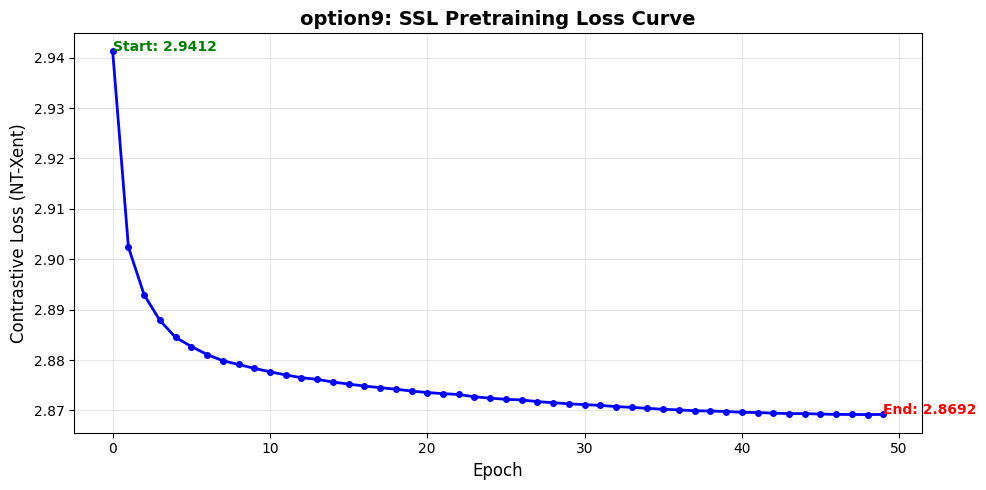

SSL Loss: 2.9412 → 2.8692 over 50 epochs


In [13]:
# ============================================
# 📈 SSL Pretraining Loss Curve
# ============================================

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pretrain_losses, 'b-', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Contrastive Loss (NT-Xent)', fontsize=12)
ax.set_title(f'{OPTION_NAME}: SSL Pretraining Loss Curve', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Annotate start and end
if len(pretrain_losses) > 0:
    ax.annotate(f'Start: {pretrain_losses[0]:.4f}', xy=(0, pretrain_losses[0]),
               fontsize=10, color='green', fontweight='bold')
    ax.annotate(f'End: {pretrain_losses[-1]:.4f}', xy=(len(pretrain_losses)-1, pretrain_losses[-1]),
               fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(str(checkpoint_dir), f'{OPTION_NAME}_ssl_loss_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"SSL Loss: {pretrain_losses[0]:.4f} → {pretrain_losses[-1]:.4f} over {len(pretrain_losses)} epochs")


## 11. Fine-tuning

In [14]:
# Initialize classification model with pretrained backbone
# Start with backbone frozen if freeze_backbone_epochs > 0
initial_freeze = cfg.freeze_backbone_epochs > 0
classifier = ClassificationModel(
    ssl_model,
    num_classes=len(disease_categories),
    dropout_rate=cfg.dropout_rate,
    freeze_backbone=initial_freeze
).to(cfg.device)

# FocalLoss with configurable gamma, alpha, and label smoothing
criterion = FocalLoss(
    alpha=cfg.focal_alpha,
    gamma=cfg.focal_gamma,
    label_smoothing=cfg.label_smoothing
)

# AdamW with differential learning rates
backbone_lr = cfg.finetune_lr * cfg.backbone_lr_multiplier
optimizer = optim.AdamW([
    {'params': classifier.backbone.parameters(), 'lr': backbone_lr},
    {'params': classifier.classifier.parameters(), 'lr': cfg.finetune_lr},
], weight_decay=cfg.weight_decay)

# LR Scheduler (with optional warmup)
if cfg.scheduler_type == "cosine":
    effective_epochs = cfg.finetune_epochs - cfg.warmup_epochs
    base_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(1, effective_epochs), eta_min=1e-7
    )
else:  # plateau
    base_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=cfg.patience
    )

# Wrap with warmup if warmup_epochs > 0
if cfg.warmup_epochs > 0:
    scheduler = LinearWarmupScheduler(optimizer, cfg.warmup_epochs, base_scheduler)
else:
    scheduler = base_scheduler

n_params = sum(p.numel() for p in classifier.parameters())
n_trainable = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
print(f"Classifier total params: {n_params:,}, trainable: {n_trainable:,}")
print(f"Optimizer: AdamW (backbone_lr={backbone_lr:.2e}, head_lr={cfg.finetune_lr:.2e})")
print(f"Loss: FocalLoss(alpha={cfg.focal_alpha}, gamma={cfg.focal_gamma}, label_smoothing={cfg.label_smoothing})")
print(f"Scheduler: {cfg.scheduler_type} + warmup={cfg.warmup_epochs} epochs")
if initial_freeze:
    print(f"🥶 Backbone FROZEN for first {cfg.freeze_backbone_epochs} epochs")

best_auc = 0
train_losses = []
val_aucs = []
patience_counter = 0
FINETUNE_START_EPOCH = 1

if RESUME_FINETUNING:
    ckpt_file = find_latest_checkpoint(f'{OPTION_NAME}_finetune') if FINETUNE_CHECKPOINT_FILE == "latest" else FINETUNE_CHECKPOINT_FILE
    if ckpt_file:
        ft_ckpt = load_checkpoint(ckpt_file)
        if ft_ckpt:
            classifier.load_state_dict(ft_ckpt['classifier'])
            if 'optimizer' in ft_ckpt:
                try:
                    optimizer.load_state_dict(ft_ckpt['optimizer'])
                except:
                    print("⚠️ Optimizer state incompatible, starting fresh")
            if 'scheduler_state' in ft_ckpt:
                try:
                    if hasattr(scheduler, "after_scheduler") and scheduler.after_scheduler is not None:
                        scheduler.after_scheduler.load_state_dict(ft_ckpt['scheduler_state'])
                    else:
                        scheduler.load_state_dict(ft_ckpt['scheduler_state'])
                except:
                    print("⚠️ Scheduler state incompatible, starting fresh")
            train_losses = ft_ckpt.get('train_losses', train_losses)
            val_aucs = ft_ckpt.get('val_aucs', val_aucs)
            best_auc = ft_ckpt.get('best_auc', 0)
            patience_counter = ft_ckpt.get('patience_counter', 0)
            FINETUNE_START_EPOCH = ft_ckpt['epoch'] + 1
            print(f"🔄 Resuming fine-tuning from epoch {FINETUNE_START_EPOCH} (best AUC: {best_auc:.4f})")
    else:
        print("⚠️ No fine-tuning checkpoint found. Starting fresh.")

if FINETUNE_START_EPOCH > cfg.finetune_epochs:
    print(f"✅ Fine-tuning already complete ({cfg.finetune_epochs} epochs)")
else:
    print(f"\n🎯 Starting Fine-tuning")
    print(f"   Epochs: {FINETUNE_START_EPOCH} → {cfg.finetune_epochs}")
    print(f"   Training data: {len(train_loader.dataset):,} samples (fraction={cfg.finetune_fraction})")
    print("=" * 50)
    SAVE_EVERY = 5
    
    for epoch in range(FINETUNE_START_EPOCH, cfg.finetune_epochs + 1):
        # === Backbone freeze/unfreeze strategy ===
        if cfg.freeze_backbone_epochs > 0 and epoch == cfg.freeze_backbone_epochs + 1:
            classifier.unfreeze_backbone()
            # Reset optimizer with fresh momentum for unfrozen params
            optimizer = optim.AdamW([
                {'params': classifier.backbone.parameters(), 'lr': backbone_lr},
                {'params': classifier.classifier.parameters(), 'lr': cfg.finetune_lr},
            ], weight_decay=cfg.weight_decay)
            # Reset scheduler for remaining epochs
            remaining_epochs = cfg.finetune_epochs - epoch + 1
            if cfg.scheduler_type == "cosine":
                base_scheduler = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=max(1, remaining_epochs), eta_min=1e-7
                )
            else:
                base_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='max', factor=0.5, patience=cfg.patience
                )
            scheduler = base_scheduler
            n_trainable = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
            print(f"\n🔥 Backbone UNFROZEN at epoch {epoch}! Trainable params: {n_trainable:,}")
        
        train_loss = finetune_epoch(
            classifier, train_loader, optimizer, criterion, cfg.device,
            gradient_clip_val=cfg.gradient_clip_val
        )
        val_auc, _ = evaluate(classifier, val_loader, cfg.device)
        
        train_losses.append(train_loss)
        val_aucs.append(val_auc)
        
        # Step scheduler
        if isinstance(scheduler, LinearWarmupScheduler):
            scheduler.step(metrics=val_auc)
        elif cfg.scheduler_type == "plateau":
            scheduler.step(val_auc)
        else:
            scheduler.step()
        
        current_lr = optimizer.param_groups[0]['lr']
        current_head_lr = optimizer.param_groups[1]['lr']
        print(f"Epoch {epoch}/{cfg.finetune_epochs} - Loss: {train_loss:.4f}, Val AUC: {val_auc:.4f}, LR(bb): {current_lr:.2e}, LR(head): {current_head_lr:.2e}")
        
        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(classifier.state_dict(), checkpoint_dir / 'option9_ssl_best.pth')
            save_checkpoint({
                'epoch': epoch, 'classifier': classifier.state_dict(),
                'val_auc': val_auc,
            }, f'{OPTION_NAME}_best_model.pth')
            print(f"  ✅ Best model saved! Val AUC: {val_auc:.4f}")
            patience_counter = 0
        else:
            patience_counter += 1
        
        if epoch % SAVE_EVERY == 0 or epoch == cfg.finetune_epochs:
            # Get scheduler state
            sched_state = None
            if hasattr(scheduler, "after_scheduler") and scheduler.after_scheduler is not None:
                sched_state = scheduler.after_scheduler.state_dict()
            elif hasattr(scheduler, "state_dict"):
                sched_state = scheduler.state_dict()
            save_checkpoint({
                'epoch': epoch, 'classifier': classifier.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler_state': sched_state,
                'train_losses': train_losses, 'val_aucs': val_aucs,
                'best_auc': best_auc, 'patience_counter': patience_counter,
            }, f'{OPTION_NAME}_finetune_latest.pth')
        
        if patience_counter >= cfg.early_stopping_patience:
            print(f"⏹️ Early stopping at epoch {epoch} (no improvement for {cfg.early_stopping_patience} epochs)")
            break

print(f"\n✅ Fine-tuning complete. Best Val AUC: {best_auc:.4f}")


Classifier total params: 23,533,582, trainable: 28,686
Optimizer: AdamW (backbone_lr=5.00e-05, head_lr=5.00e-04)
Loss: FocalLoss(alpha=1.0, gamma=2.0, label_smoothing=0.05)
Scheduler: cosine + warmup=3 epochs
🥶 Backbone FROZEN for first 3 epochs

🎯 Starting Fine-tuning
   Epochs: 1 → 100
   Training data: 103,847 samples (fraction=1)


Evaluating: 100%|██████████| 94/94 [00:20<00:00,  4.58it/s]


Epoch 1/100 - Loss: 0.0640, Val AUC: 0.6111, LR(bb): 2.00e-05, LR(head): 2.00e-04
💾 Saved: option9_best_model.pth
  ✅ Best model saved! Val AUC: 0.6111


Evaluating: 100%|██████████| 94/94 [00:08<00:00, 11.57it/s]


Epoch 2/100 - Loss: 0.0509, Val AUC: 0.6633, LR(bb): 3.50e-05, LR(head): 3.50e-04
💾 Saved: option9_best_model.pth
  ✅ Best model saved! Val AUC: 0.6633


...

Fine-tuning:  50%|█████     | 817/1623 [03:38<03:44,  3.59it/s, loss=0.0458]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Evaluating: 100%|██████████| 94/94 [00:08<00:00, 11.48it/s]


Epoch 32/100 - Loss: 0.0417, Val AUC: 0.7983, LR(bb): 3.98e-05, LR(head): 3.98e-04
💾 Saved: option9_best_model.pth
  ✅ Best model saved! Val AUC: 0.7983


Fine-tuning:  41%|████▏     | 670/1623 [02:26<03:30,  4.53it/s, loss=0.0387]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Evaluating: 100%|██████████| 94/94 [00:08<00:00, 11.04it/s]


Epoch 49/100 - Loss: 0.0401, Val AUC: 0.7958, LR(bb): 2.71e-05, LR(head): 2.70e-04


Fine-tuning:  21%|██▏       | 348/1623 [01:17<04:42,  4.51it/s, loss=0.0369]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



## 12. Evaluation

In [ ]:
# Load best model
best_model_path = os.path.join(CHECKPOINT_DIR, f'{OPTION_NAME}_best_model.pth')
checkpoint = load_checkpoint(f'{OPTION_NAME}_best_model.pth')
if checkpoint:
    classifier.load_state_dict(checkpoint['classifier'])
    print(f"✅ Loaded best model (Val AUC: {checkpoint.get('val_auc', 'N/A')})")
else:
    # Fallback to legacy path
    legacy_path = checkpoint_dir / 'option9_ssl_best.pth'
    if legacy_path.exists():
        classifier.load_state_dict(torch.load(legacy_path, map_location=cfg.device, weights_only=False))
        print('✅ Loaded best model from legacy path')
    else:
        print('⚠️ No best model found!')

# Evaluate on test set
test_auc, disease_aucs = evaluate(classifier, test_loader, cfg.device)

print(f"\n{'='*50}")
print(f"TEST RESULTS - Option 6 SSL (Segmentation Channel)")
print(f"{'='*50}")
print(f"\nOverall Test AUC: {test_auc:.4f}")
print(f"\nPer-disease AUC scores:")
print("-" * 40)

for disease, auc in zip(disease_categories, disease_aucs):
    print(f"{disease:20s}: {auc:.4f}")

print(f"\n{'='*50}")

: 

: 

: 

## 13. Visualization

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pretraining loss
axes[0].plot(pretrain_losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Contrastive Loss')
axes[0].set_title('SSL Pretraining Loss')
axes[0].grid(True, alpha=0.3)

# Fine-tuning loss
axes[1].plot(train_losses, 'g-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('BCE Loss')
axes[1].set_title('Fine-tuning Loss')
axes[1].grid(True, alpha=0.3)

# Validation AUC
axes[2].plot(val_aucs, 'r-', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].set_title('Validation AUC')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(checkpoint_dir / 'option9_ssl_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Disease-wise AUC bar plot
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 0.8, len(disease_categories)))
bars = ax.bar(disease_categories, disease_aucs, color=colors)
ax.axhline(y=test_auc, color='red', linestyle='--', linewidth=2, label=f'Mean AUC: {test_auc:.4f}')
ax.set_xlabel('Disease')
ax.set_ylabel('AUC Score')
ax.set_title('Option 9 SSL - Per-Disease AUC Scores')
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(checkpoint_dir / 'option9_ssl_disease_aucs.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualizations saved")

## 14. Sample Predictions Visualization

In [ ]:
# Visualize sample predictions
classifier.eval()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax_row in enumerate(axes):
    for j, ax in enumerate(ax_row):
        idx = i * 4 + j
        sample, label = test_dataset[idx]
        
        with torch.no_grad():
            pred = torch.sigmoid(classifier(sample.unsqueeze(0).to(cfg.device)))
        
        # Show original image (channel 0)
        ax.imshow(sample[0].numpy(), cmap='gray')
        
        # Show mask as overlay
        mask_overlay = sample[1].numpy()
        ax.imshow(mask_overlay, cmap='Reds', alpha=0.3)
        
        # Get top predictions
        pred_np = pred.cpu().numpy().flatten()
        top_idx = pred_np.argsort()[-3:][::-1]
        
        title_lines = []
        for tidx in top_idx:
            if pred_np[tidx] > 0.3:
                title_lines.append(f"{disease_categories[tidx][:8]}: {pred_np[tidx]:.2f}")
        
        ax.set_title('\n'.join(title_lines) if title_lines else 'No Finding', fontsize=8)
        ax.axis('off')

plt.suptitle('Sample Predictions (Image + Segmentation Overlay)', fontsize=12)
plt.tight_layout()
plt.savefig(checkpoint_dir / 'option9_ssl_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Sample predictions visualized")

## Summary

This notebook implemented **Option 9 with SSL**:

1. **2-Channel Input**: Combined grayscale image + rule-based lung segmentation mask
2. **SSL Pretraining**: Contrastive learning (NT-Xent loss) to learn representations
3. **Fine-tuning**: Multi-label classification for 14 diseases

### Key Benefits:
- Preserves all original image information
- Provides anatomical context through segmentation channel
- SSL pretraining helps learn robust features before supervised learning
- Consistent augmentations applied to both image and mask channels